<a href="https://www.kaggle.com/code/riteshkumarweb/k-means-clustering-algorithm?scriptVersionId=323478666" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from sklearn.datasets import make_blobs

# Coordinates of the centers (means) of the 4 clusters in 3D space.
# Each tuple represents (x, y, z) coordinates of a cluster center.
centroids = [
    (-5, -5, 5),    # Cluster 1 center
    (5, 5, -5),     # Cluster 2 center
    (3.5, -2.5, 4), # Cluster 3 center
    (-2.5, 2.5, -4) # Cluster 4 center
]

# Standard deviation (spread) of points around each cluster center.
# Smaller value = points are tightly packed around the centroid.
# Larger value = points are more scattered.
# Here, all clusters have the same spread of 1.
cluster_std = [1, 1, 1, 1]

X,y = make_blobs(n_samples=200, cluster_std=cluster_std, centers=centroids, n_features=3, random_state=1)

X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

In [4]:
import plotly.express as px

fig = px.scatter_3d(
    x=X[:, 0],  # ':' = all rows, '0' = first column (Feature 1)
    y=X[:, 1],  # ':' = all rows, '1' = second column (Feature 2)
    z=X[:, 2]   # ':' = all rows, '2' = third column (Feature 3)
)

fig.show()  # Opens the 3D visualization in the notebook/browser

In [10]:
from sklearn.cluster import KMeans

wcss = []  # Store WCSS values

for i in range(1, 21):  # Test K from 1 to 20
    km = KMeans(n_clusters=i)  # Create K-Means model
    km.fit_predict(X)          # Train model and assign clusters
    wcss.append(km.inertia_)   # Save WCSS

print(wcss)  # Print all WCSS values

[[11143.784324503365, 4122.409557603532, 2552.3917334076905, 593.2516262404544, 553.3698603561522, 504.4606820206686, 461.1069009421297, 441.00917516375875, 404.17424593603914, 387.91656691499065, 368.201099602265, 326.14033572231654, 318.769438363258, 300.88834008986953, 283.1800213858966, 271.83139238036006, 261.6430152619648, 248.2732370581473, 234.23419264374633, 227.72837552881327]]


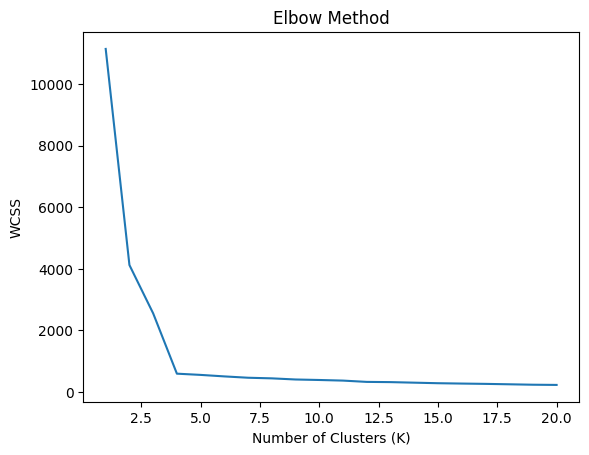

In [21]:
import matplotlib.pyplot as plt

plt.plot(
    range(1, 21),  # X-axis: Number of clusters (K) from 1 to 20
    wcss           # Y-axis: Corresponding WCSS values
)

plt.xlabel("Number of Clusters (K)")  # Label for X-axis
plt.ylabel("WCSS")                    # Label for Y-axis
plt.title("Elbow Method")             # Title of the graph

plt.show()  # Display the plot

In [24]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(
    n_samples=300,
    n_features=2,
    centers=3,
    random_state=42
)
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,    # Number of clusters to find
    random_state=42  # Ensures same initial centroids every run
)
kmeans.fit(X)  # Compute centroids and assign each point to the nearest centroid
print(kmeans.labels_)  
# Array of cluster labels for all samples
# Example: [1, 0, 2, 1, 1, 0, ...]
print(kmeans.cluster_centers_)  
# Final centroid locations
# Shape: (2, n_features)
# Since X has 2 features, shape will be (2, 2)

[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


# How to Choose K?
The biggest challenge in K-Means is selecting the correct number of clusters.

# Elbow Method
Train K-Means with different K values.

In [25]:
inertia = []  # Store WCSS values

for k in range(1, 11):  # Test K from 1 to 10
    km = KMeans(n_clusters=k, random_state=42)  # Create K-Means model
    km.fit(X)                                   # Fit model to data
    inertia.append(km.inertia_)                 # Save WCSS value

print(inertia)                                  # Display all WCSS values

[20402.344442926296, 5763.464789461435, 566.8595511244132, 497.033988149521, 428.2142129932839, 375.0659248776243, 308.1983661041826, 272.4057314987482, 234.28072349591133, 219.0405333899988]


# Plot K vs Inertia

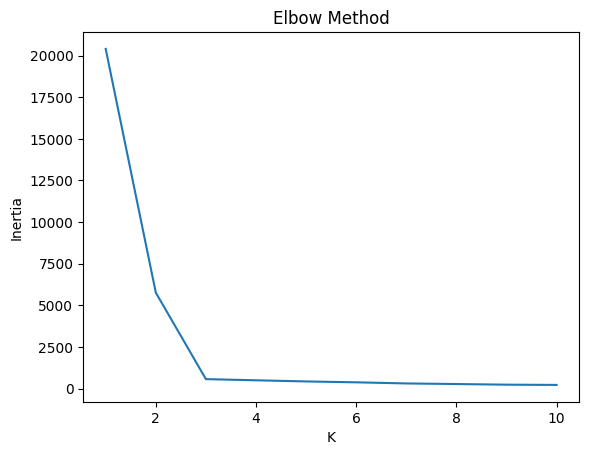

In [26]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), inertia)  # Plot K values against inertia values

plt.xlabel("K")                  # Number of clusters
plt.ylabel("Inertia")            # WCSS (Within-Cluster Sum of Squares)
plt.title("Elbow Method")        # Used to find the optimal K

plt.show()                       # Display the graph

In [29]:
kmeans.cluster_centers_
# Coordinates of the cluster centroids.
# Shape = (n_clusters, n_features)
#
# Example:
# [[ 4.7  2.0]
#  [-2.6  9.0]
#  [-6.8 -6.9]]
#
# 3 clusters and 2 features
# Each row = one centroid

array([[-2.63323268,  9.04356978],
       [-6.88387179, -6.98398415],
       [ 4.74710337,  2.01059427]])

In [ ]:
#Centroid 0 = [ 4.7,  2.0]
#Centroid 1 = [-2.6,  9.0]
#Centroid 2 = [-6.8, -6.9]

In [ ]:
#          y
#          ↑

#      C1 (-2.6, 9.0)
##
#
  #                        C0 (4.7, 2.0)


# C2 (-6.8, -6.9)

────────────────────────────→ x
#This is Centroid 

In [28]:
kmeans.labels_
# Array containing the cluster number assigned to each sample.
# Example:
# [0 1 1 2 0 2 1 ...]
# First sample belongs to cluster 0
# Second sample belongs to cluster 1
# Third sample belongs to cluster 1

array([1, 1, 0, 2, 1, 2, 0, 2, 0, 0, 0, 2, 0, 0, 1, 0, 1, 2, 0, 0, 0, 0,
       2, 1, 0, 1, 1, 2, 2, 0, 0, 0, 1, 0, 1, 0, 1, 2, 1, 2, 2, 0, 1, 2,
       0, 0, 1, 2, 1, 2, 2, 1, 1, 0, 1, 2, 1, 0, 2, 0, 1, 2, 2, 1, 1, 2,
       2, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 2, 0, 2, 0, 0, 1, 0, 2, 1, 1, 0,
       2, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2, 1,
       2, 0, 0, 0, 0, 2, 1, 2, 1, 2, 2, 2, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 2, 2, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 2, 0, 0, 1, 2, 1,
       0, 2, 2, 1, 1, 0, 0, 1, 1, 1, 0, 1, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2,
       2, 0, 2, 2, 1, 0, 1, 2, 2, 1, 2, 0, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2,
       0, 1, 0, 0, 2, 2, 0, 2, 1, 1, 2, 0, 0, 1, 2, 2, 1, 1, 1, 1, 0, 1,
       1, 2, 1, 1, 0, 2, 1, 1, 2, 0, 0, 1, 0, 1, 2, 2, 1, 2, 1, 1, 1, 2,
       2, 0, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 0, 1, 0, 0, 0, 1, 0,
       2, 2, 1, 2, 2, 0, 0, 2, 2, 2, 1, 1, 1, 0, 0, 0, 2, 2, 2, 2, 1, 2,
       1, 2, 2, 1, 0, 2, 2, 0, 1, 0, 2, 0, 1, 1], d

In [27]:
km.inertia_
# Total squared distance of all points from their nearest centroid.
# Used in the Elbow Method.
# Lower inertia = tighter clusters.

219.0405333899988